# Hydrostatic simulation on pearl millet root

Simulate root of millet for two genotype, run hydraulic simulation using hydrostatic solver with two different soils

In [1]:
import pandas as pd
import numpy as np

# Import 2D and 3D viewer with PlantGL
from openalea.plantgl.algo.view import view # 2D view
from openalea.widgets.plantgl import PlantGL # notebook viewer 3D

# plot
import matplotlib.pyplot as plt

# Import HydroRoot modules
from openalea import hydroroot
from openalea.hydroroot import (
    main,
    radius,
    display,
)
from openalea.hydroroot.millet import (
    turtle,
    law,
    age,
    architecture,
    conductance,
)

%matplotlib inline

## Compute architecture from architectural parameters and laws

| Lineage | Number of plants | Mean (+/- std) Seminal Root Length (cm) | Mean Number Coronair Roots (+/- std) | Mean Number Lateral roots (+/- std)  |
|-------|----------------|----------------------------------------------|-----------------------------------------|----------------------------------------|
| 57    | 46             | 10.3 (6.4)                                   | 0.17 (0.68)                             | 3.1 (3.9)                              |
| 109   | 76             | 20.2 (8.6)                                   | 0.54 (1.1)                              | 14.1 (14.3)                            |


In [2]:
g57 = hydroroot.millet.architecture.millet_generator(
    seed=1,
    primary_length=0.103,
    nude_tip_length=0.03,
    nb_crown=1,
    n_laterals_primary=3,   # explicit count
    lateral_length=0.02,
    segment_length=1e-4,     
)
g109 = hydroroot.millet.architecture.millet_generator(
    seed=1,
    primary_length=0.202,
    nude_tip_length=0.03,
    nb_crown=4,
    n_laterals_primary=14,   # explicit count
    lateral_length=0.05,
    segment_length=1e-4,    
)

## Compute length and position MTG properties

In [3]:
g57 = hydroroot.radius.compute_length(g57)
g57 = hydroroot.radius.compute_relative_position(g57)
g109 = hydroroot.radius.compute_length(g109)
g109 = hydroroot.radius.compute_relative_position(g109)

## Compute diameter property using evolution laws

- **Load diameter data for the different root types**

Data are (x,y) csv with position x in cm and root diameter y in µm

In [4]:
sr_xy = pd.read_csv("data/SR_diameters.csv", delimiter=";")
cr_xy = pd.read_csv("data/CR_diameters.csv", delimiter=";")
lr_xy = pd.read_csv("data/LR_diameters.csv", delimiter=";")

- **Estimate the laws from the data by determing the best params of the affine function**

Position and diameters are converted to meter, then data is normalized on x and are fitted with an affine function.

In [5]:
affine_f = lambda x, a, b: a * x + b
sr_diam_law = hydroroot.millet.law.diameter_fit_law(sr_xy, function=affine_f, scale_x=0.01, scale_y=1e-6, plot=False)
cr_diam_law = hydroroot.millet.law.diameter_fit_law(cr_xy, function=affine_f, scale_x=0.01, scale_y=1e-6, plot=False)
lr_diam_law = hydroroot.millet.law.diameter_fit_law(lr_xy, function=affine_f, scale_x=0.01, scale_y=1e-6, plot=False)

- **Calculate diameter and radius for both genotypes**

In [6]:
# calculate diameter
g57 = hydroroot.millet.law.compute_diam_radius_from_laws(g57, seminal_RootDiameter_law= sr_diam_law,crown_RootDiameter_law= cr_diam_law,lr_RootDiameter_law= lr_diam_law)
g109 = hydroroot.millet.law.compute_diam_radius_from_laws(g109, seminal_RootDiameter_law= sr_diam_law,crown_RootDiameter_law= cr_diam_law,lr_RootDiameter_law= lr_diam_law)

## Compute Days After Germination of each vertex on the MTG

In [7]:
g57 = hydroroot.millet.age.compute_dag_with_constant_growth_speed(g57)
g109 = hydroroot.millet.age.compute_dag_with_constant_growth_speed(g109)

## Visualizing architectures

* 57

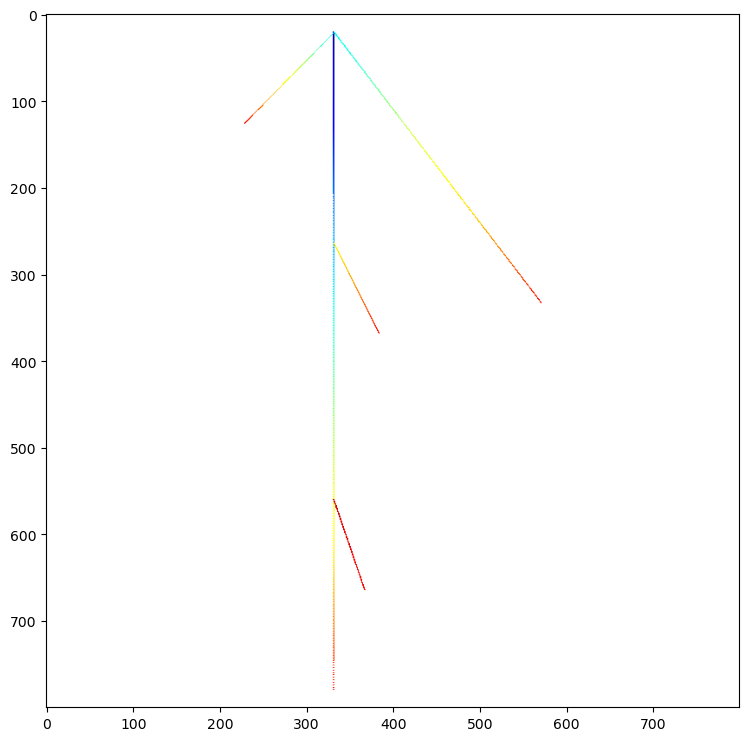

/home/bauget/Documents/Dev/hydroroot/src/openalea/hydroroot/display.py:290: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


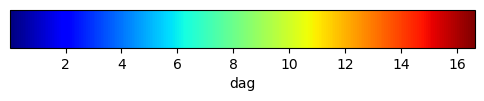

In [8]:
s = hydroroot.display.mtg_scene(g57,prop_cmap='dag')
view(s) 
hydroroot.display.property_scale_bar(g57, 'dag')

* **109**

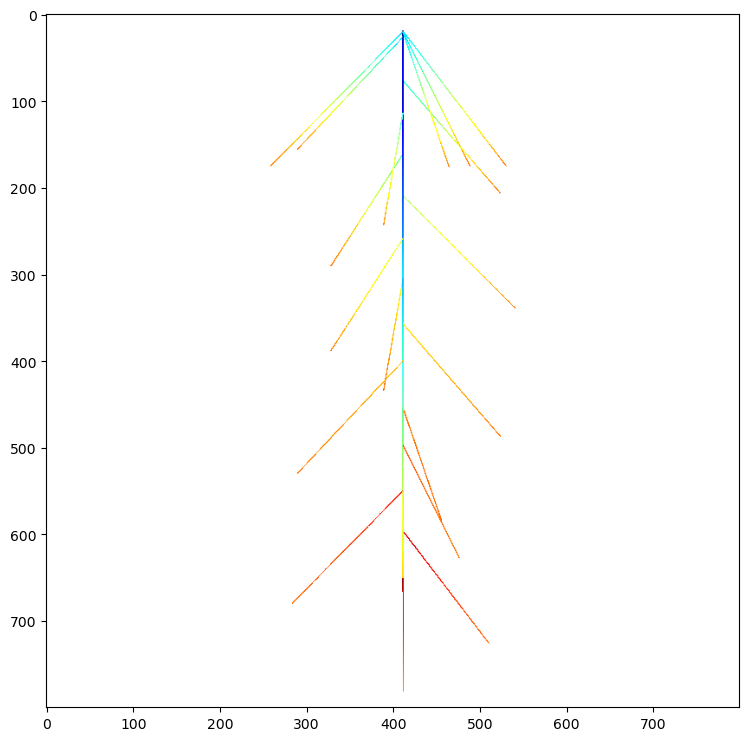

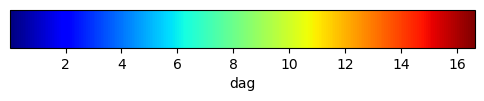

In [9]:
s = hydroroot.display.mtg_scene(g109,prop_cmap='dag')
view(s) # use PlantGL(s) to display in 3D
hydroroot.display.property_scale_bar(g57, 'dag')

## Calculation of axial conductances K from the evolution laws

### Define K laws for the different root types

sr_law stands for deminal roots, cr_law for crown roots and lr_law for lateral roots. K is in $m^3.MPa^{-1}.s^{-1}$

In [10]:
# Laws are defined with respect to relative position, so experimental laws are slightly modified
sr_law = lambda x: 2135.05* (x * 29.5) + 21338.63 # x is replace by r * xmax where r is the relative position
cr_law = lambda x: 9228.45* (x *17.4) + 42600.14
lr_law = lambda x: 2951.65* (x * 13.6) + 2720.09

### Compute K for both genotypes

In [11]:
g57 = hydroroot.millet.conductance.compute_K_from_laws(g57, sr_law, cr_law, lr_law)
g109 = hydroroot.millet.conductance.compute_K_from_laws(g109, sr_law, cr_law, lr_law)

 ## Compute surface and volume for the lines

In [12]:
g57, surface57 = hydroroot.radius.compute_surface(g57)
g57, volume57 = hydroroot.radius.compute_volume(g57)
g109, surface109 = hydroroot.radius.compute_surface(g109)
g109, volume109 = hydroroot.radius.compute_volume(g109)

In [13]:
print( f'57: surface = {surface57: .2e} m2, volume = {volume57: .2e} m3')
print( f'109: surface = {surface109: .2e} m2, volume = {volume109: .2e} m3')

57: surface =  9.37e-05 m2, volume =  3.26e-09 m3
109: surface =  4.30e-04 m2, volume =  1.32e-08 m3


## Compute the radial conductances

### Define Radial conductivity versus distance to tip

In [14]:
# radial conductivity profile: distance to tip (m) vs kr (10-9 m.s-1.MPa-1)
kx57=np.array([0.0, 0.11]) # distance to tip
ky57=np.array([300, 300]) # kr
k_radial_data57=(kx57,ky57)

kx109=np.array([0.0, 0.21]) # distance to tip
ky109=np.array([300, 300]) # kr
k_radial_data109=(kx109,ky109)

## Use HydroRoot model to compute Water flux

In [15]:
g57, keq57, jv57 = hydroroot.main.hydroroot_flow(g57, psi_e = 0.4, psi_base = 0.1,
                            radial_conductivity_data = k_radial_data57)
g109, keq109, jv109 = hydroroot.main.hydroroot_flow(g109, psi_e = 0.4, psi_base = 0.1,
                            radial_conductivity_data = k_radial_data109)

### Visualizing water fluxes for two architecturally contrasted millet lines

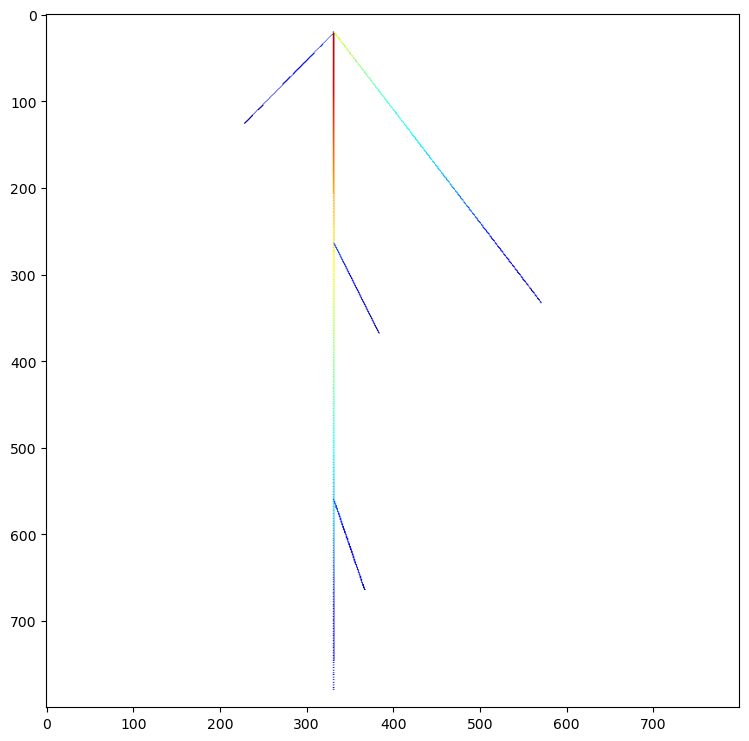

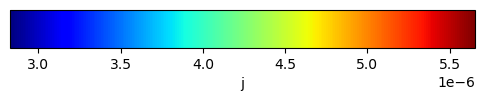

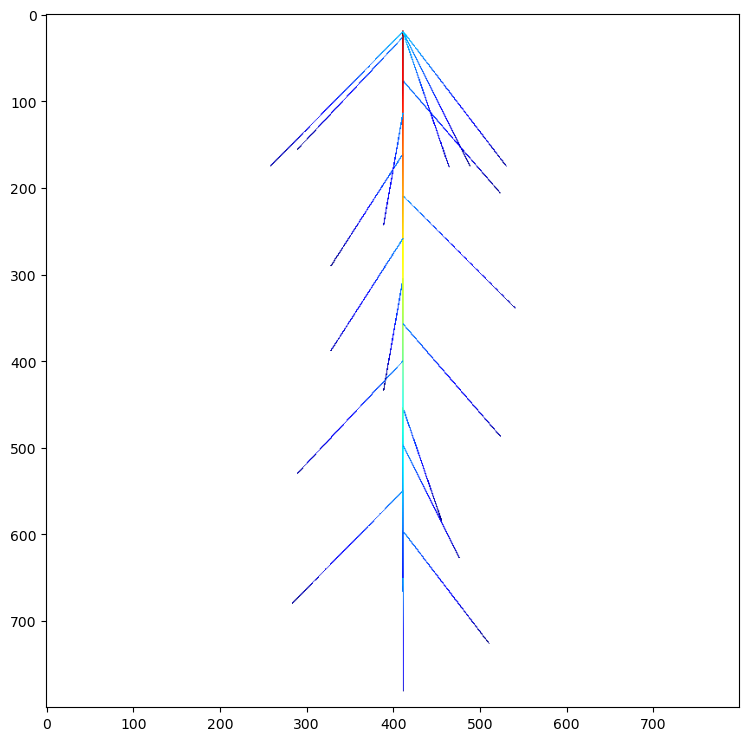

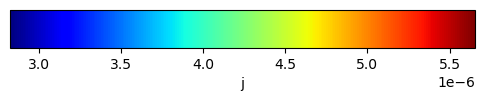

In [16]:
s57 = hydroroot.display.mtg_scene(g57,prop_cmap='j') #, visitor=hydroroot.millet.turtle.visitor_millet) # calling visitor 2 allows to get the xyz position of every node
s109 = hydroroot.display.mtg_scene(g109,prop_cmap='j') #, visitor=hydroroot.millet.turtle.visitor_millet)
# use PlantGL(s) to display in 3D
# PlantGL(s57)
# PlantGL(s109)
view(s57) 
hydroroot.display.property_scale_bar(g57, 'j')
view(s109) 
hydroroot.display.property_scale_bar(g109, 'j')

In [17]:
print(f'Global water flux 57 (microL/s): {jv57:.3e}')
print(f'Global water flux 109 (microL/s): {jv109:.3e}')

Global water flux 57 (microL/s): 8.436e-03
Global water flux 109 (microL/s): 3.863e-02


## Add Soil and compute $\Psi_e$

Here we simulate 1D soil. The soil model is a superposition of layers with increasing heterogeneous water potential that varies with depth, unlike the pressure chamber, where potential is homogeneous and constant everywhere.
We will simulate two different soils:

1. a sandy soil where pearl millet traditionally grows in farm conditions.
2. a less sandy soil to illustrate effect of the water potential profile
   
Soil potential profile $\Psi_e(depth)$ with in MPa versus depth in m.

### Soil potential

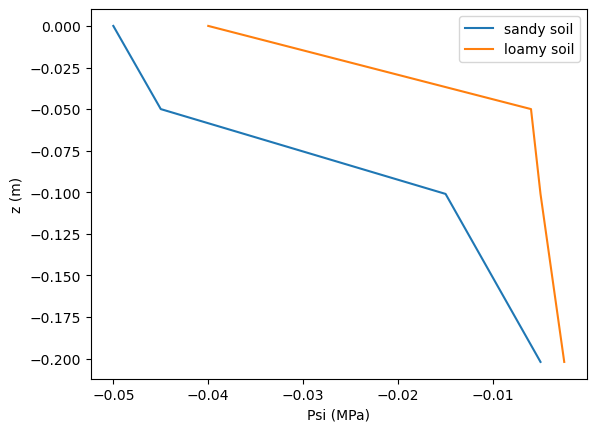

In [18]:
# sandy_soil_potential = (
# [0.0, 0.0202, 0.101, 0.202],
# [0.1, 0.1, 0.4, 0.8]
# )
sandy_soil_potential = (
[0.0, 0.05, 0.101, 0.202],
[-0.05, -0.045, -0.015, -0.005]
)
x_sandy, y_sandy = np.array(sandy_soil_potential)

# loamy_soil_potential = (
# [0.0, 0.0202, 0.101, 0.202],
# [0.1, 0.3, 0.6, 0.8]
# )
loamy_soil_potential = (
[0.0, 0.05, 0.101, 0.202],
[-0.04, -0.006, -0.005, -0.0025]
)
x_other, y_other = np.array(loamy_soil_potential)

plt.plot(y_sandy, -1*x_sandy, label='sandy soil')
plt.plot(y_other, -1*x_other, label='loamy soil')
plt.xlabel('Psi (MPa)')
plt.ylabel('z (m)')
plt.legend()

### Water potential at the collet

Here we simulate a soil with a negative water potential. We also simulate transpiration with a negative water potential at the collet.

In [19]:
P_base = -0.1

### xyz position of vertices

‘xyz’ MTG property is calculated using a visitor in `hydroroot.display.mtg_scene`. Root three dimensional geometries are synthetic, root angles are randomly set according to realistic 

In [20]:
s57 = hydroroot.display.mtg_scene(g57,prop_cmap='j', visitor=hydroroot.millet.turtle.visitor_millet) 
s109 = hydroroot.display.mtg_scene(g109,prop_cmap='j', visitor=hydroroot.millet.turtle.visitor_millet)

### Sandy soil

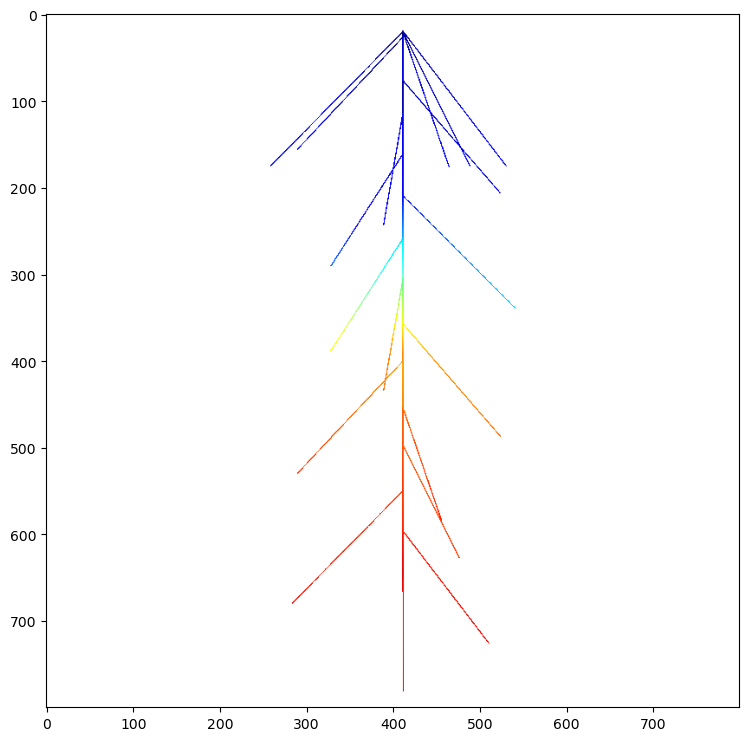

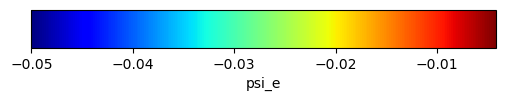

In [21]:
g57_s = hydroroot.main.soil_1D(g57, sandy_soil_potential)
g109_s = hydroroot.main.soil_1D(g109, sandy_soil_potential)
# s57 = hydroroot.display.mtg_scene(g57,prop_cmap='psi_e') 
s109 = hydroroot.display.mtg_scene(g109,prop_cmap='psi_e')
# view(s57)
view(s109)
hydroroot.display.property_scale_bar(g109, 'psi_e')

### Recompute the water fluxes with the heterogenous external water potential

In [22]:
g57_f, keq57_f, jv57_f = hydroroot.main.hydroroot_flow(g57_s, psi_e = None, psi_base = P_base,
                            radial_conductivity_data = k_radial_data57)
g109_f, keq109_f, jv109_f = hydroroot.main.hydroroot_flow(g109_s, psi_e = None, psi_base = P_base,
                            radial_conductivity_data = k_radial_data109)
print(f'Global water flux 57 (microL/s): {jv57_f:.3e}')
print(f'Global water flux 109 (microL/s): {jv109_f:.3e}')

Global water flux 57 (microL/s): 1.619e-03
Global water flux 109 (microL/s): 9.004e-03


### Visualize water fluxes in sandy soils

Here we use some fake radii greater than the real ones to ease visualization.

In [23]:
s57_s = hydroroot.display.mtg_scene(g57_f.copy(),prop_cmap='j', visitor=hydroroot.millet.turtle.visitor_millet, has_radius=False, r_base=1e-3, r_tip=0.5e-3)
s109_s = hydroroot.display.mtg_scene(g109_f.copy(),prop_cmap='j', visitor=hydroroot.millet.turtle.visitor_millet, has_radius=False, r_base=1e-3, r_tip=0.5e-3)

In [24]:
# PlantGL(s57_s)
PlantGL(s109_s)

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

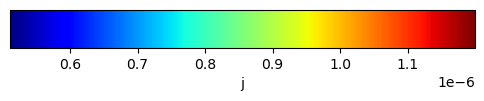

In [25]:
hydroroot.display.property_scale_bar(g109_f, 'j')

### With another soil potential

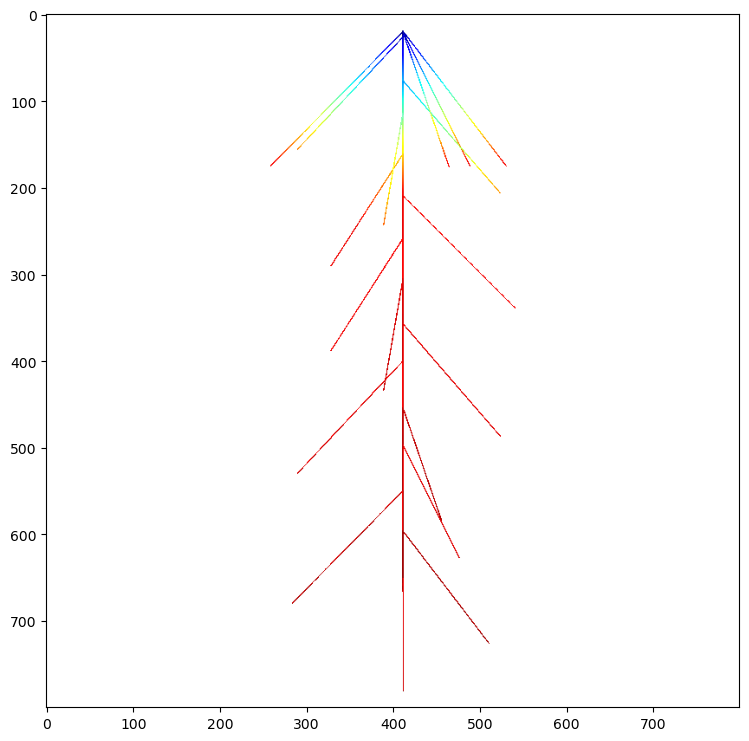

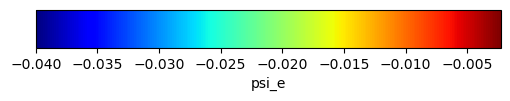

In [26]:
g57_s = hydroroot.main.soil_1D(g57, loamy_soil_potential)
g109_s = hydroroot.main.soil_1D(g109, loamy_soil_potential)
# s57 = hydroroot.display.mtg_scene(g57,prop_cmap='psi_e') 
s109 = hydroroot.display.mtg_scene(g109,prop_cmap='psi_e')
# view(s57)
view(s109)
hydroroot.display.property_scale_bar(g109, 'psi_e')

In [27]:
g57_f, keq57_f, jv57_f = hydroroot.main.hydroroot_flow(g57_s, psi_e = None, psi_base = P_base,
                            radial_conductivity_data = k_radial_data57)
g109_f, keq109_f, jv109_f = hydroroot.main.hydroroot_flow(g109_s, psi_e = None, psi_base = P_base,
                            radial_conductivity_data = k_radial_data109)
print(f'Global water flux 57 (microL/s): {jv57_f:.3e}')
print(f'Global water flux 109 (microL/s): {jv109_f:.3e}')

Global water flux 57 (microL/s): 2.286e-03
Global water flux 109 (microL/s): 1.137e-02


In [28]:
s57_s = hydroroot.display.mtg_scene(g57_f.copy(),prop_cmap='j', visitor=hydroroot.millet.turtle.visitor_millet, has_radius=False, r_base=1e-3, r_tip=0.5e-3)
s109_s = hydroroot.display.mtg_scene(g109_f.copy(),prop_cmap='j', visitor=hydroroot.millet.turtle.visitor_millet, has_radius=False, r_base=1e-3, r_tip=0.5e-3)
# PlantGL(s57)
PlantGL(s109_s)
# view(s109_s)

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

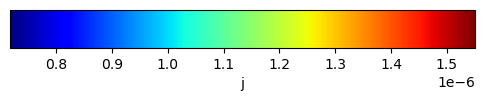

In [29]:
hydroroot.display.property_scale_bar(g109_f, 'j')